# Cylinder Flow (Reference) DEMO code

This notebook demonstrates solving steady-state Flow around cylinder with the same setup as this paper https://arxiv.org/abs/2002.10558, using the optional NGSolve reference solver instead of a PINN.

In [1]:
import deepflow as df
print("Deepflow is runned on:", df.device) # to change to cpu use df.device = 'cpu'

Deepflow is runned on: cuda


## 1. Define Geometry Domain
Set up the computational domain: a rectangle with a circular obstacle (cylinder). This defines the area for simulation.

In [2]:
circle = df.geometry.circle(0.2, 0.2, 0.05)
rectangle = df.geometry.rectangle([0,1.1], [0,0.41])
area = rectangle - circle

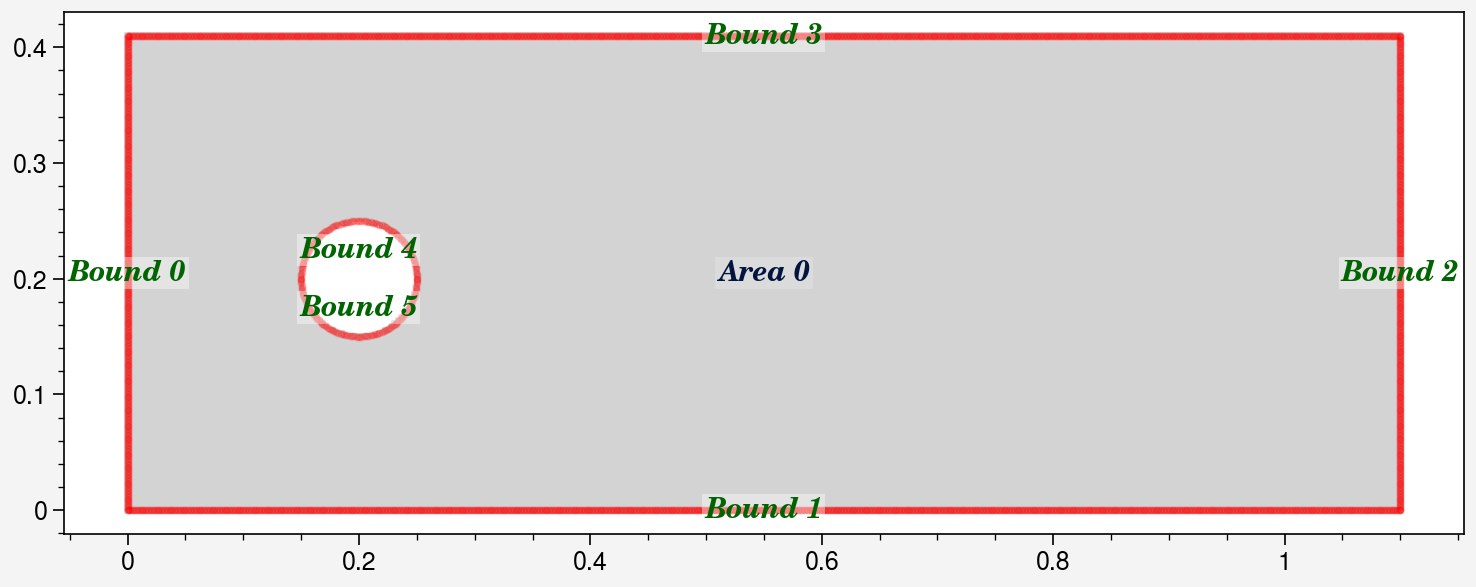

In [3]:
domain = df.domain(area, circle.bound_list)
domain.show_setup()

## 2. Define Physics
Define the Navier-Stokes equations for fluid flow and apply boundary conditions (e.g., no-slip walls, inlet velocity).

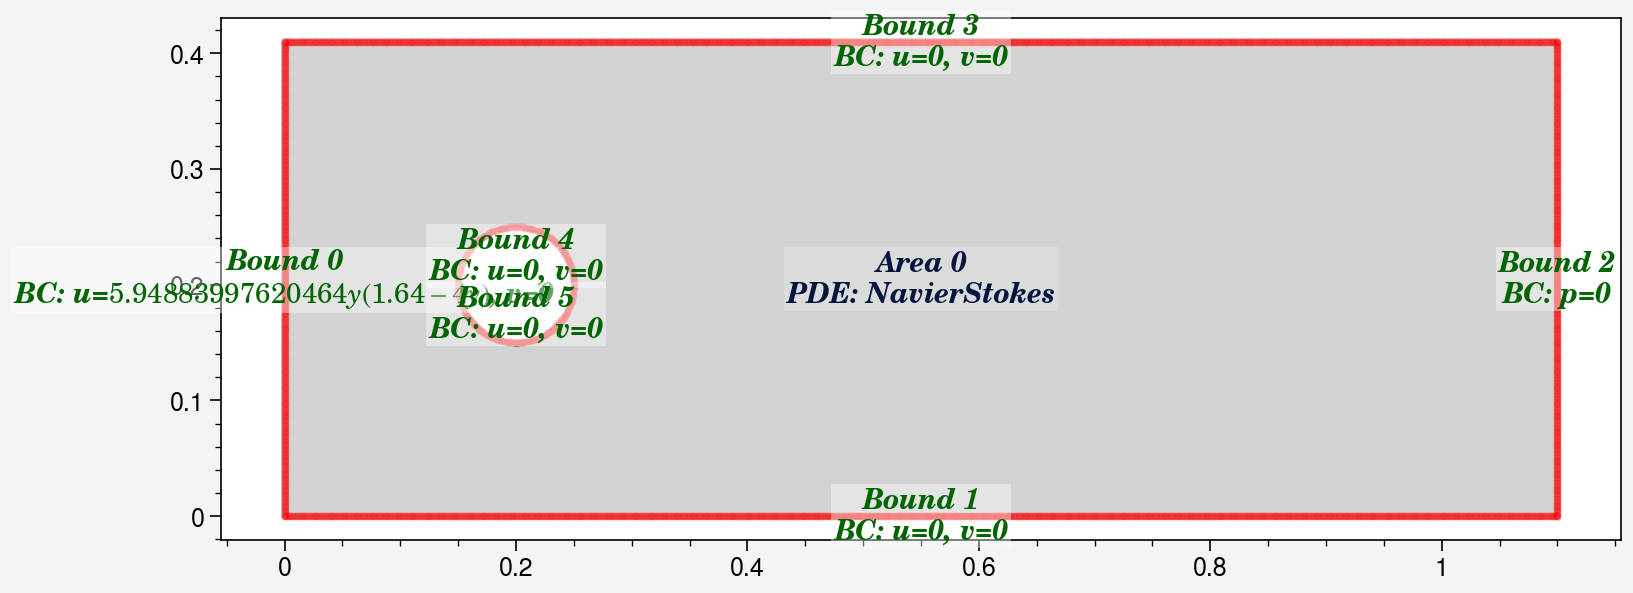

In [4]:
domain.bound_list[0].define_bc({'u': ['y', lambda x:  4*1*(0.41-x)*x/0.41**2], 'v': 0})
domain.bound_list[1].define_bc({'u': 0,'v': 0})
domain.bound_list[2].define_bc({'p': 0})
domain.bound_list[3].define_bc({'u': 0,'v': 0})
domain.bound_list[4].define_bc({'u': 0, 'v': 0})
domain.bound_list[5].define_bc({'u': 0, 'v': 0})
area.define_pde(df.NavierStokes(U=1, L=1, mu=0.02, rho=1))
domain.show_setup()

## 3. Solve with FEM evaluation
Solve the steady Navier-Stokes equations with the optional NGSolve/Netgen finite-element backend. The returned GroupEvaluator keeps FEM fields per geometry and exposes the advanced ReferenceSolution.

In [5]:
reference_solution = domain.solve_fem(
    mesh_size=0.05,
    boundary_resolution=64,
    max_iterations=200,
)
print(reference_solution.metadata)

{'backend': 'NGSolve/Netgen', 'pde': 'NavierStokes', 'fields': ['u', 'v', 'p'], 'mesh_size': 0.05, 'mesh': {'dimension': 2, 'elements': 2564, 'vertices': 1473}, 'boundary_labels': {'outer_0001': {'hole': False, 'bound_id': 1404000712400}, 'outer_0002': {'hole': False, 'bound_id': 1404000713232}, 'outer_0003': {'hole': False, 'bound_id': 1404000714448}, 'outer_0000': {'hole': False, 'bound_id': 1404000711568}, 'hole_0001': {'hole': True, 'bound_id': 1403990884112}, 'hole_0000': {'hole': True, 'bound_id': 1403990015312}}, 'iterations': 10, 'solver_residuals': [0.9959511894038658, 0.1432602012174619, 0.012051180980336786, 0.0012373896084839566, 8.361890122356545e-05, 8.411137332653031e-06, 1.8477982405596168e-06, 1.9212164970200534e-07, 1.172877555895597e-08, 3.0404698043213622e-09], 'converged': True, 'pressure_gauge': 'configured Dirichlet', 'derived_fields': []}


## 4. Visualization

### 4.1 Visualize area

In [6]:
import numpy as np

area_x, area_y = area.sampling_area([300, 150])
x_data = area_x.detach().cpu().numpy()
y_data = area_y.detach().cpu().numpy()
values = reference_solution.evaluate(x_data, y_data, fields=['u', 'v', 'p'])
area_data = {
    'x': x_data,
    'y': y_data,
    **{f'{name}_ref': values[name] for name in ['u', 'v', 'p']},
}
area_eval = df.Visualizer(area_data)
print(area_eval.data_dict.keys())

Available data keys: ('u_ref', 'v_ref', 'p_ref', 'x', 'y')


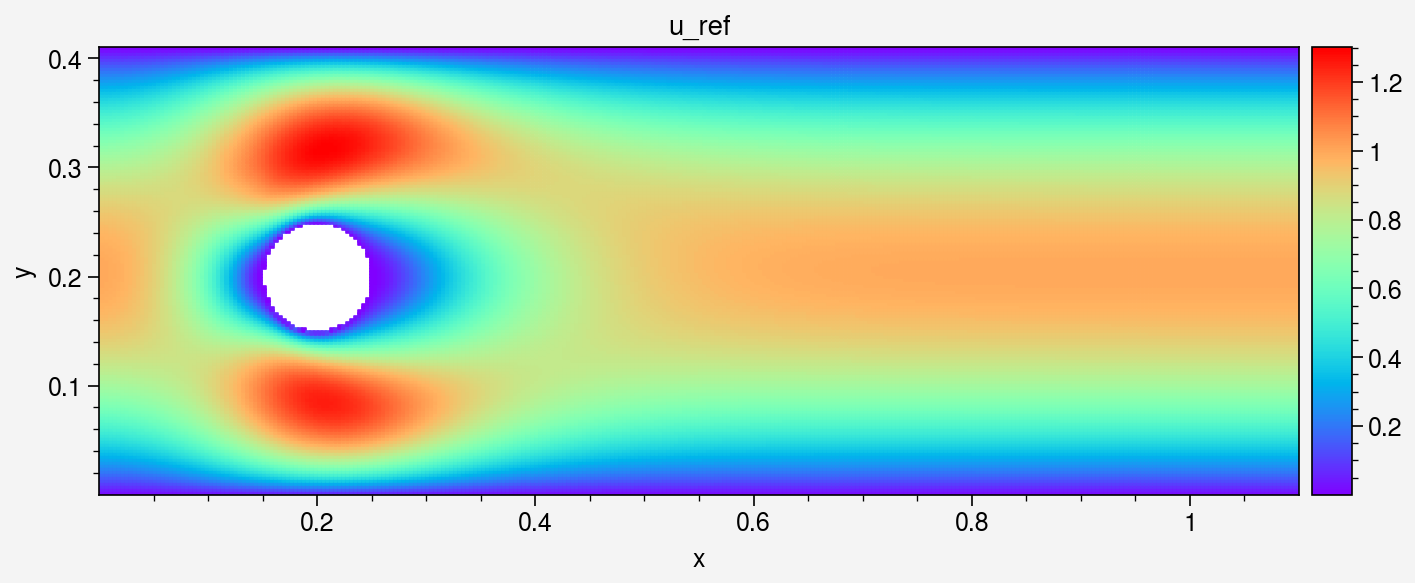

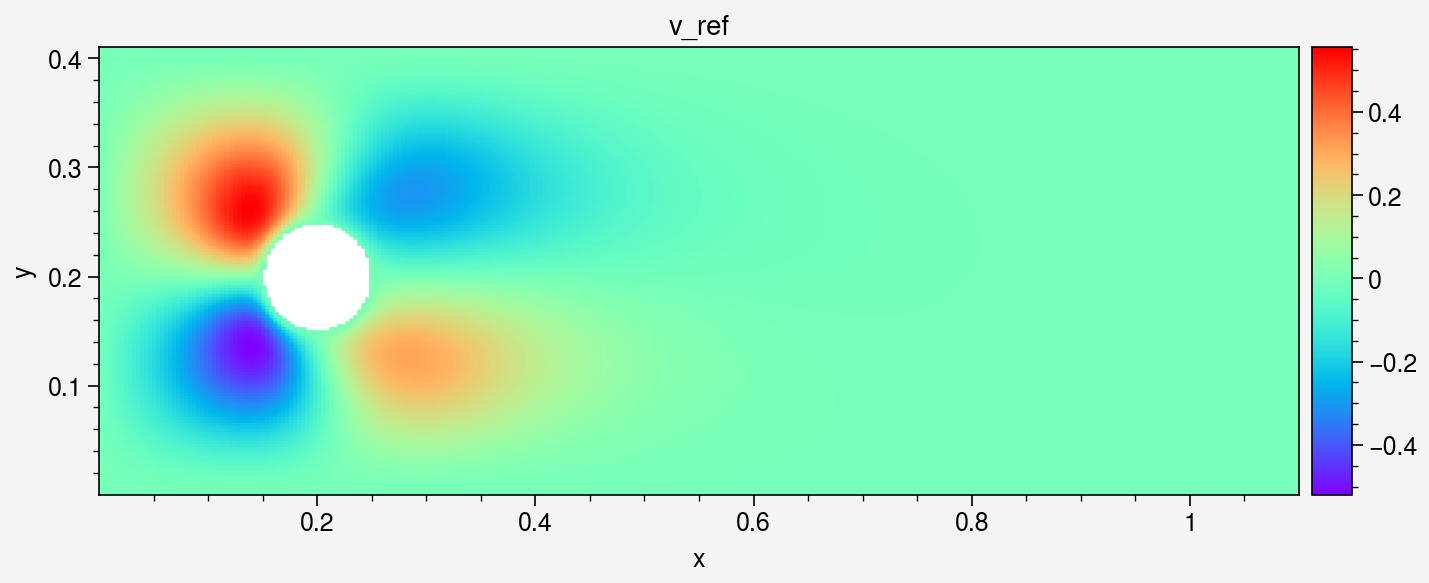

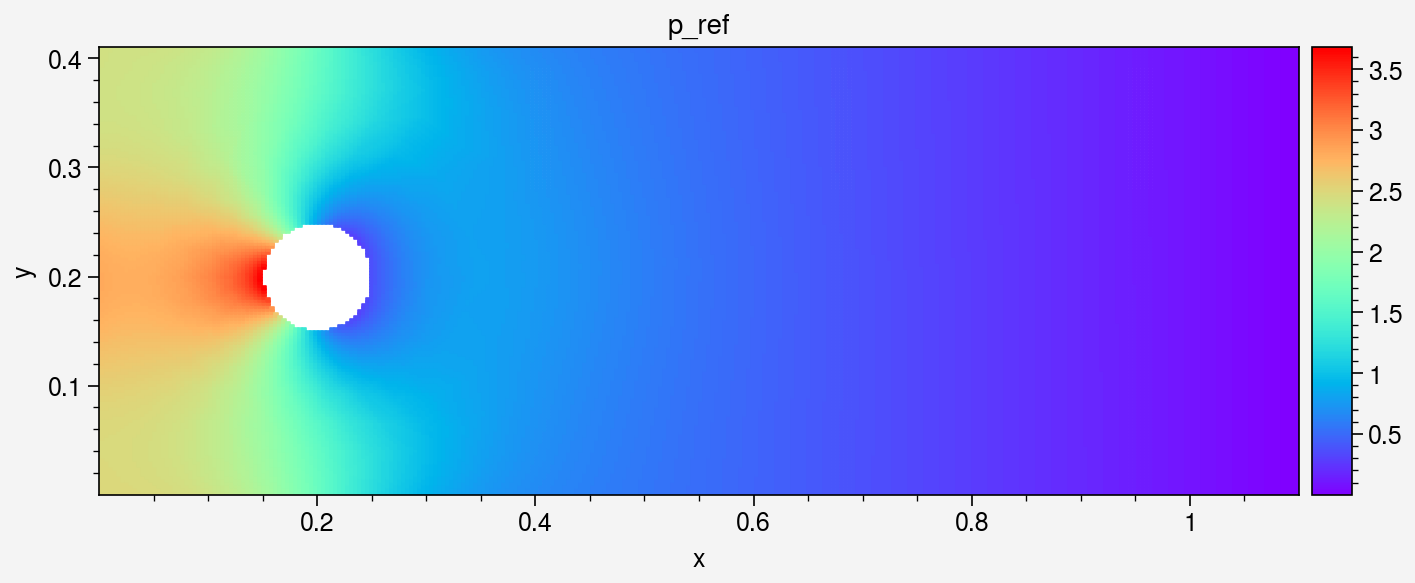

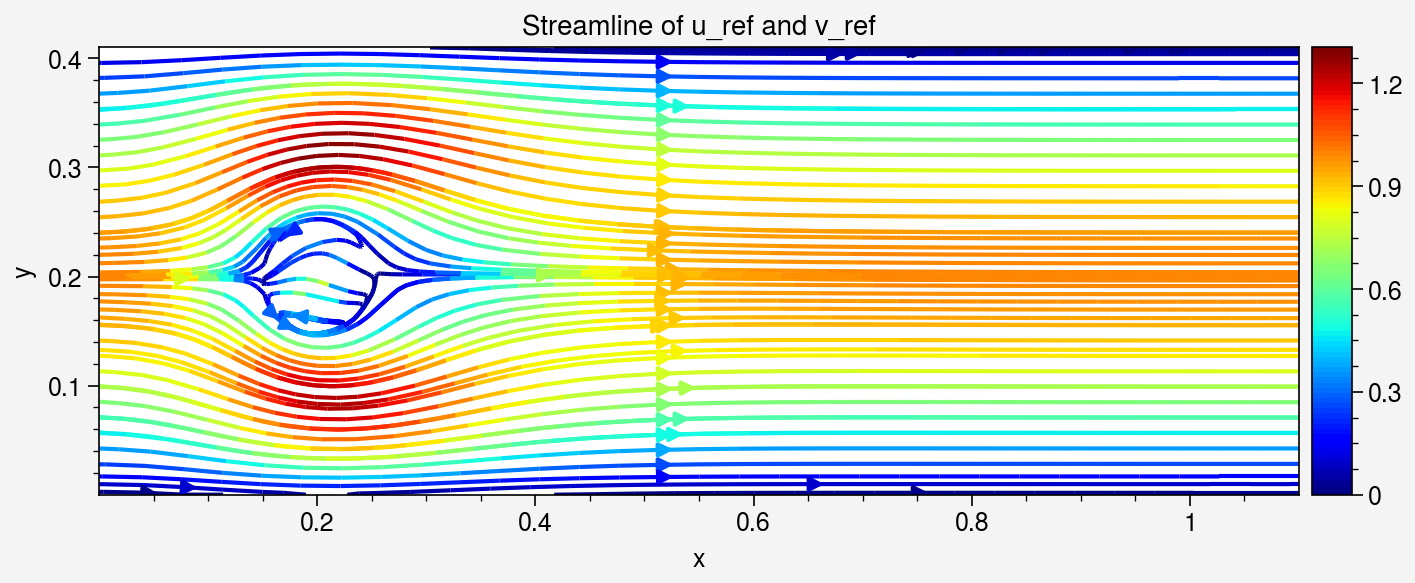

In [7]:
area_eval.plot_color('u_ref', s=2, cmap='rainbow').savefig("colorplot_u.png")
_ = area_eval.plot_color('v_ref', s=2, cmap='rainbow')
_ = area_eval.plot_color('p_ref', s=2, cmap='rainbow')
_ = area_eval.plot_streamline('u_ref', 'v_ref', cmap='jet')

### 4.2 Visualize outlet

u range: 9.697474598072365e-06 1.0000089309075013


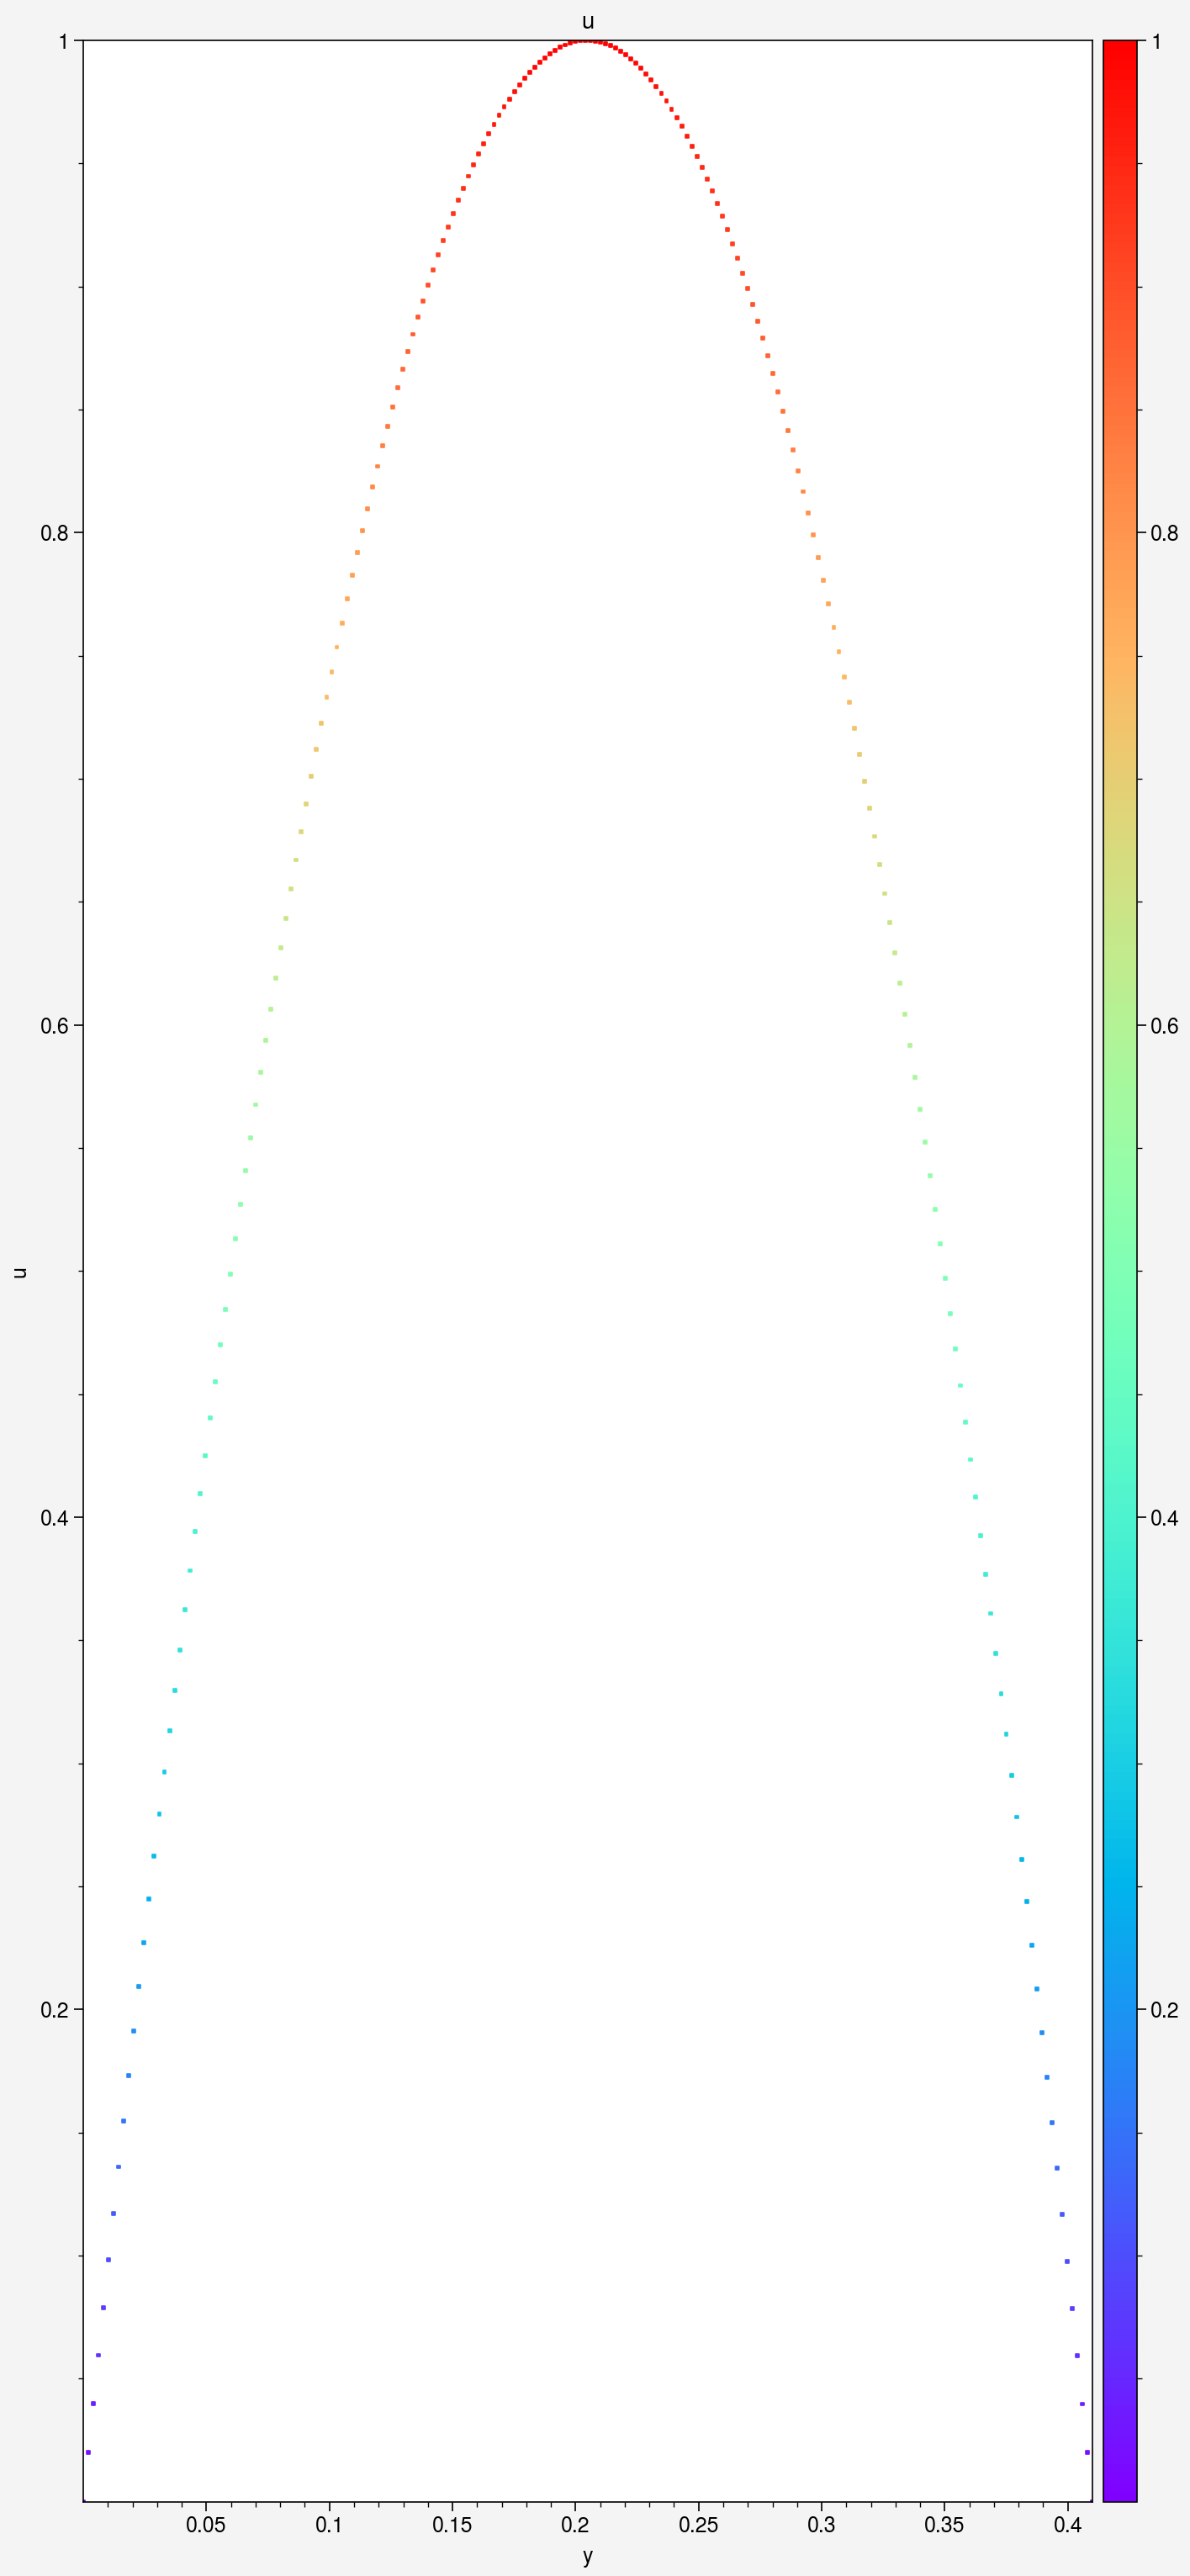

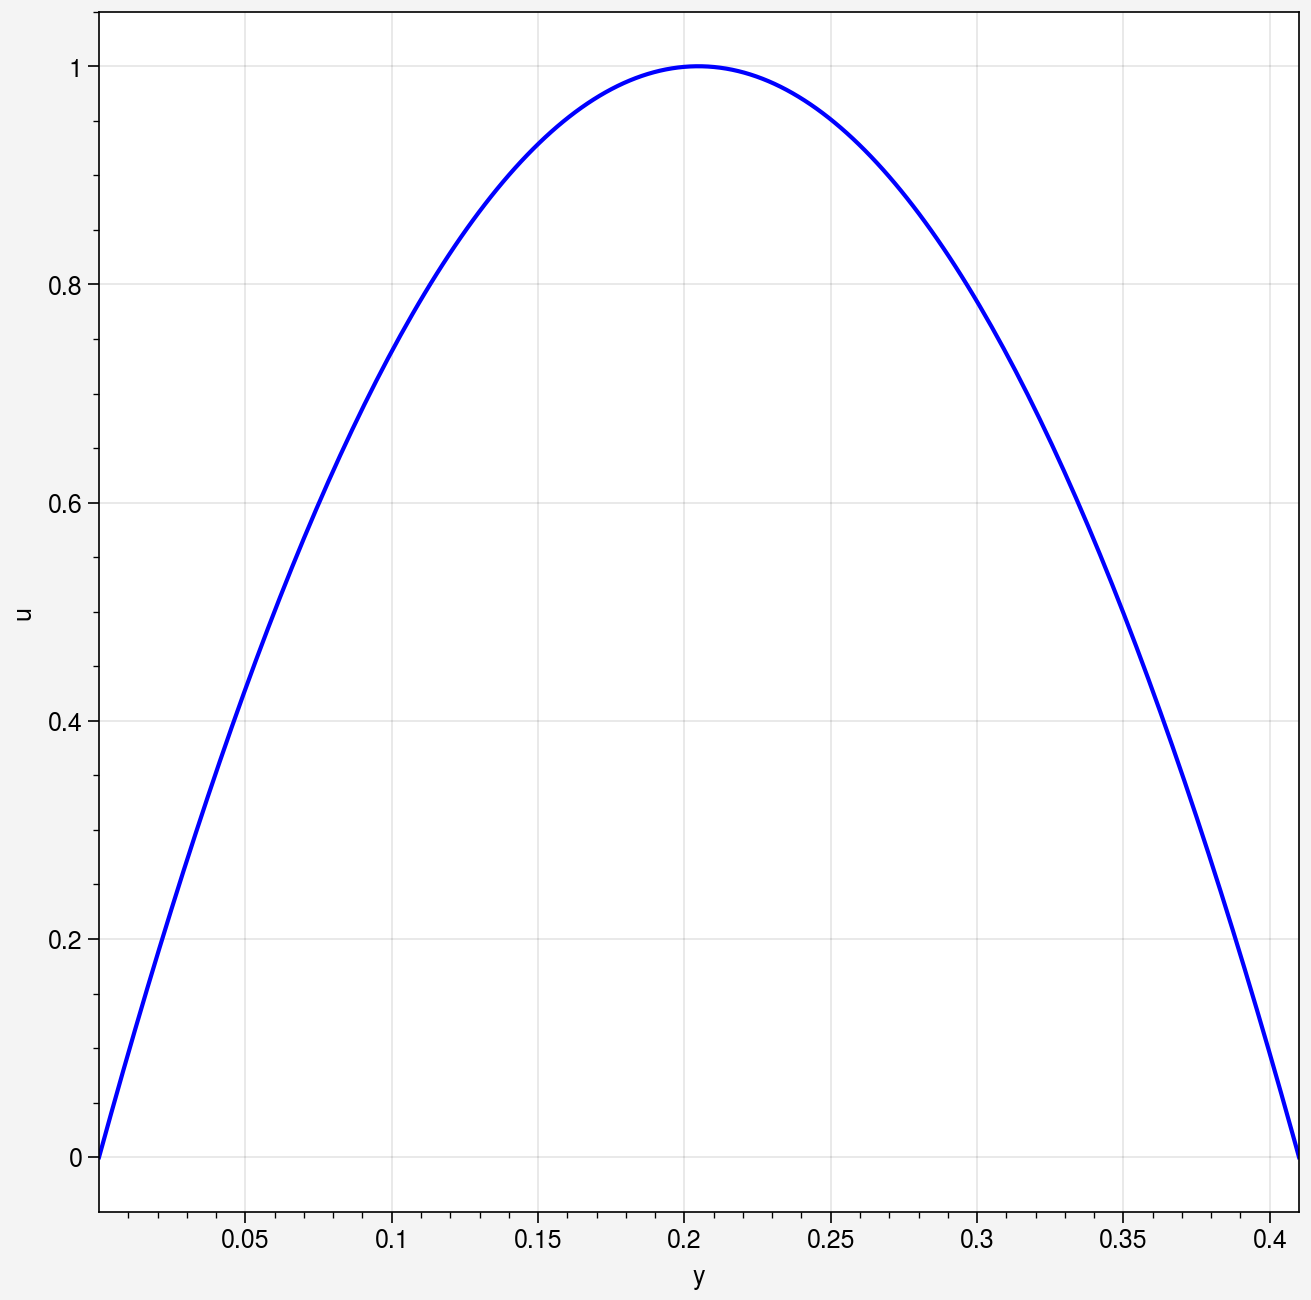

In [8]:
# Sample points just inside the outlet at x = 1.1
outlet_x = np.full(200, 1.1 - 1e-6)
outlet_y = np.linspace(1e-6, 0.41 - 1e-6, 200)
outlet_values = reference_solution.evaluate(outlet_x, outlet_y, fields=['u', 'v', 'p'])
print('u range:', outlet_values['u'].min(), outlet_values['u'].max())

# Create object for evaluation
bound_visual = df.Visualizer({'x': outlet_x, 'y': outlet_y, **outlet_values})
_ = bound_visual.plot_color('u', x_axis='y', y_axis='u', cmap='rainbow')
_ = bound_visual.plot(x_axis = 'y', y_axis='u')

### 4.3 Visualize solver data

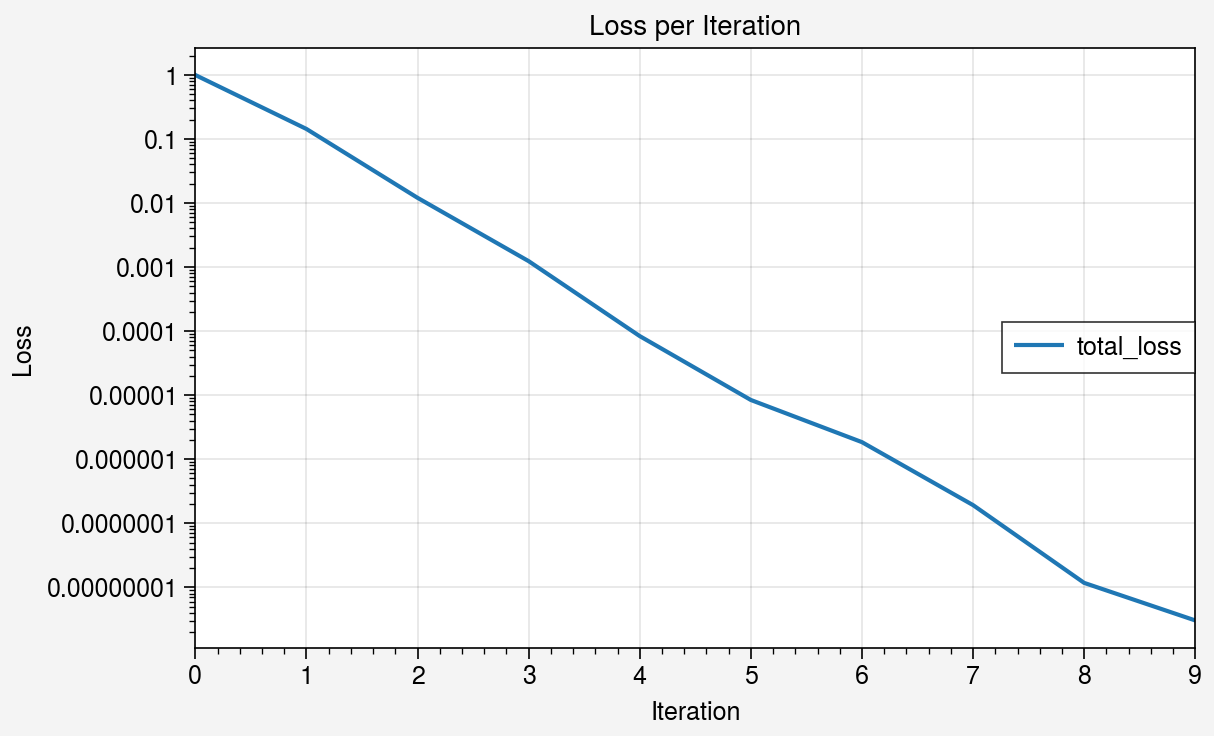

In [9]:
solver_visual = df.Visualizer({'total_loss': np.asarray(reference_solution.metadata['solver_residuals'])})
_ = solver_visual.plot_loss_curve(log_scale=True)

### 4.4 Export data

In [10]:
# store the x,y,u,v,p data
reference_solution.export_npz(
    'cylinder_reference.npz',
    x=x_data,
    y=y_data,
    fields=['u', 'v', 'p'],
)

# store the outlet x,y,u data
array = np.column_stack((outlet_x, outlet_y, outlet_values['u']))
np.savetxt('outlet_velocity.txt', array)
print('Saved cylinder_reference.npz and outlet_velocity.txt')

Saved cylinder_reference.npz and outlet_velocity.txt
